# Halo Analysis 2.1

This notebook streamlines the boundary-centered halo workflow for a 3-class U-Net segmentation model and keeps only the **validated spatial calibration**:

- **Calibration:** `6.15 pixels / µm`
- **Pixel size:** `1 / 6.15 µm / pixel`
- **Pixel area:** `(1 / 6.15)^2 µm² / pixel`

## Halo geometry
- **H1**: 4 px band *inside* the nuclear perimeter
- **H2**: nuclear perimeter reference halo
- **H3**: first 4 px band *outside* the perimeter
- **H4**: second 4 px band *outside* the perimeter

## Main outputs
- full `T × Z` measurement table
- largest cross-sectional area per time point
- time-course plots for:
  - `nc_ratio_um2_denominator`
  - `nuclear_area_um2`


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import napari
import matplotlib.pyplot as plt
import tensorflow as tf
import tifffile

from scipy import ndimage as ndi
from skimage.transform import resize
from skimage.morphology import remove_small_objects, remove_small_holes
from skimage.measure import label


## Paths and data loading

In [3]:
DATA_ROOT = Path("C:/Users/cowboy/OneDrive/Documents/Unviversity of Alabama")
IMAGE_ROOT = DATA_ROOT / "Nuclear_Scaling/Data_Sets/Control/Extract_3"

IMAGE_PATH = IMAGE_ROOT / "Region 1/Droplet 1/Region 1 Droplet 1 .tif"
MODEL_PATH = DATA_ROOT / "Nuclear_Scaling/Machine_Learning_Models/unet_droplet_nucleus_best_1.2.h5"

assert IMAGE_PATH.exists(), f"Image not found at {IMAGE_PATH}"
assert MODEL_PATH.exists(), f"Model not found at {MODEL_PATH}"

with tifffile.TiffFile(IMAGE_PATH) as tif:
    print("Number of series:", len(tif.series))
    for i, s in enumerate(tif.series):
        print(f"Series {i}")
        print("  shape:", s.shape)
        print("  axes:", s.axes)
        print("  dtype:", s.dtype)

img = tifffile.imread(IMAGE_PATH)
model = tf.keras.models.load_model(MODEL_PATH)

print("Image shape:", img.shape)
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)


Number of series: 1
Series 0
  shape: (10, 20, 3, 392, 396)
  axes: TZCYX
  dtype: uint16


Image shape: (10, 20, 3, 392, 396)
Model input shape: (None, 512, 512, 3)
Model output shape: (None, 512, 512, 3)


## Analysis settings

In [4]:
NUCLEUS_CLASS_IDX = 2
INTENSITY_CHANNEL_IDX = 1

PRED_THRESHOLD = 0.5
MIN_OBJECT_AREA_PX = 100
HOLE_AREA_THRESHOLD = 100

HALO_STEP_PX = 4
MIN_VALID_AREA_PX = 5000
MAX_VALID_AREA_PX = 20000

EXCLUDED_TIMEPOINTS = [0, 1]

# Validated spatial calibration
PIXELS_PER_UM = 6.15
PIXEL_SIZE_UM = 1 / PIXELS_PER_UM
PIXEL_AREA_UM2 = PIXEL_SIZE_UM ** 2

print("PIXEL_SIZE_UM:", PIXEL_SIZE_UM)
print("PIXEL_AREA_UM2:", PIXEL_AREA_UM2)


PIXEL_SIZE_UM: 0.16260162601626016
PIXEL_AREA_UM2: 0.02643928878313173


## Helper functions

In [5]:
def extract_plane_yxc(img: np.ndarray, t: int, z: int) -> np.ndarray:
    """Extract one plane from TZCYX data and return (Y, X, C)."""
    return np.moveaxis(img[t, z, :, :, :], 0, -1)


def prepare_3channel_image_for_unet(image_yxc: np.ndarray, model):
    """Normalize each channel to 0-1 and resize to the model input shape."""
    if image_yxc.ndim != 3:
        raise ValueError(f"Expected (Y, X, C), got {image_yxc.shape}")
    if image_yxc.shape[-1] != 3:
        raise ValueError(f"Expected 3 channels, got {image_yxc.shape[-1]}")

    _, target_h, target_w, target_c = model.input_shape
    if target_c != 3:
        raise ValueError(f"Model expects {target_c} channels")

    original_shape = image_yxc.shape[:2]
    x = image_yxc.astype(np.float32).copy()

    for c in range(3):
        ch = x[..., c]
        ch_min = ch.min()
        ch_max = ch.max()
        if ch_max > ch_min:
            x[..., c] = (ch - ch_min) / (ch_max - ch_min)
        else:
            x[..., c] = np.zeros_like(ch, dtype=np.float32)

    x_resized = resize(
        x,
        (target_h, target_w, target_c),
        order=1,
        mode="reflect",
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float32)

    return x_resized[None, ...], original_shape


def resize_prob_map_to_original(prob_map: np.ndarray, original_shape: tuple) -> np.ndarray:
    """Resize a model output map back to the original YX shape."""
    return resize(
        prob_map,
        original_shape,
        order=1,
        mode="reflect",
        anti_aliasing=False,
        preserve_range=True,
    ).astype(np.float32)


def clean_nucleus_mask(
    nucleus_mask: np.ndarray,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    keep_largest: bool = True,
) -> np.ndarray:
    """Clean the raw binary mask and optionally keep only the largest object."""
    mask = nucleus_mask.astype(bool)
    mask = remove_small_holes(mask, area_threshold=hole_area_threshold)
    mask = remove_small_objects(mask, min_size=min_area_px)

    if keep_largest:
        lab = label(mask)
        if lab.max() > 0:
            areas = [(lab == i).sum() for i in range(1, lab.max() + 1)]
            mask = lab == (np.argmax(areas) + 1)

    return mask


def compute_signed_distance_map(nucleus_mask: np.ndarray) -> np.ndarray:
    """Negative inside the nucleus, positive outside."""
    nucleus_mask = nucleus_mask.astype(bool)
    dist_outside = ndi.distance_transform_edt(~nucleus_mask)
    dist_inside = ndi.distance_transform_edt(nucleus_mask)

    signed_dist = dist_outside.copy()
    signed_dist[nucleus_mask] = -dist_inside[nucleus_mask]
    return signed_dist


def measure_mask(mask: np.ndarray, intensity_image: np.ndarray, pixel_area_um2: float) -> dict:
    """Measure area and intensity statistics for a binary mask."""
    mask = mask.astype(bool)
    vals = intensity_image[mask]
    area_px = int(mask.sum())
    area_um2 = area_px * pixel_area_um2

    if vals.size == 0:
        return {
            "area_px": area_px,
            "area_um2": area_um2,
            "sum_intensity": 0.0,
            "mean_intensity": np.nan,
            "median_intensity": np.nan,
            "std_intensity": np.nan,
        }

    return {
        "area_px": area_px,
        "area_um2": area_um2,
        "sum_intensity": float(vals.sum()),
        "mean_intensity": float(vals.mean()),
        "median_intensity": float(np.median(vals)),
        "std_intensity": float(vals.std()),
    }


def build_boundary_centered_halos(
    signed_dist: np.ndarray,
    step_px: int = 4,
    valid_outer_mask: np.ndarray | None = None,
) -> dict:
    """
    Boundary-centered halo geometry matching the Fiji workflow.

    H1: inside band  (-step, 0]
    H2: perimeter reference halo (narrow band around 0)
    H3: first outer band (0, step]
    H4: second outer band (step, 2*step]

    Also returns cumulative outer halos for Fiji-style subtraction:
    H3_cum: (0, step]
    H4_cum: (0, 2*step]
    """
    if valid_outer_mask is None:
        valid_outer_mask = np.ones_like(signed_dist, dtype=bool)
    else:
        valid_outer_mask = valid_outer_mask.astype(bool)

    return {
        "H1": (signed_dist > -step_px) & (signed_dist <= 0),
        "H2": np.abs(signed_dist) <= 0.5,
        "H3": (signed_dist > 0) & (signed_dist <= step_px) & valid_outer_mask,
        "H4": (signed_dist > step_px) & (signed_dist <= 2 * step_px) & valid_outer_mask,
        "H3_cum": (signed_dist > 0) & (signed_dist <= step_px) & valid_outer_mask,
        "H4_cum": (signed_dist > 0) & (signed_dist <= 2 * step_px) & valid_outer_mask,
    }


def build_boundary_halo_measurement_table(
    nucleus_mask: np.ndarray,
    signed_dist: np.ndarray,
    intensity_image: np.ndarray,
    pixel_area_um2: float,
    step_px: int = 4,
    valid_outer_mask: np.ndarray | None = None,
    t: int | None = None,
    z: int | None = None,
    nucleus_id: int | None = None,
) -> pd.DataFrame:
    """Build a one-row measurement table for one nucleus in one plane."""
    nucleus_mask = nucleus_mask.astype(bool)
    halos = build_boundary_centered_halos(
        signed_dist=signed_dist,
        step_px=step_px,
        valid_outer_mask=valid_outer_mask,
    )

    nuc_stats = measure_mask(nucleus_mask, intensity_image, pixel_area_um2)
    h1_stats = measure_mask(halos["H1"], intensity_image, pixel_area_um2)
    h2_stats = measure_mask(halos["H2"], intensity_image, pixel_area_um2)
    h3_stats = measure_mask(halos["H3"], intensity_image, pixel_area_um2)
    h4_stats = measure_mask(halos["H4"], intensity_image, pixel_area_um2)
    h3_cum_stats = measure_mask(halos["H3_cum"], intensity_image, pixel_area_um2)
    h4_cum_stats = measure_mask(halos["H4_cum"], intensity_image, pixel_area_um2)

    cyto_ring_area_px = h4_cum_stats["area_px"] - h3_cum_stats["area_px"]
    cyto_ring_area_um2 = cyto_ring_area_px * pixel_area_um2
    cyto_ring_sum = h4_cum_stats["sum_intensity"] - h3_cum_stats["sum_intensity"]

    cyto_ring_mean_intensity = cyto_ring_sum / cyto_ring_area_px if cyto_ring_area_px > 0 else np.nan
    cyto_ring_mean_intensity_per_um2 = cyto_ring_sum / cyto_ring_area_um2 if cyto_ring_area_um2 > 0 else np.nan

    nc_ratio = (
        nuc_stats["mean_intensity"] / cyto_ring_mean_intensity
        if (not np.isnan(cyto_ring_mean_intensity) and cyto_ring_mean_intensity != 0)
        else np.nan
    )
    nc_ratio_um2_denominator = (
        nuc_stats["mean_intensity"] / cyto_ring_mean_intensity_per_um2
        if (not np.isnan(cyto_ring_mean_intensity_per_um2) and cyto_ring_mean_intensity_per_um2 != 0)
        else np.nan
    )

    row = {
        "nuclear_area_px": nuc_stats["area_px"],
        "nuclear_area_um2": nuc_stats["area_um2"],
        "nuclear_sum_intensity": nuc_stats["sum_intensity"],
        "nuclear_mean_intensity": nuc_stats["mean_intensity"],
        "nuclear_median_intensity": nuc_stats["median_intensity"],
        "nuclear_std_intensity": nuc_stats["std_intensity"],
        "H1_area_px": h1_stats["area_px"],
        "H1_area_um2": h1_stats["area_um2"],
        "H1_mean_intensity": h1_stats["mean_intensity"],
        "H1_sum_intensity": h1_stats["sum_intensity"],
        "H2_area_px": h2_stats["area_px"],
        "H2_area_um2": h2_stats["area_um2"],
        "H2_mean_intensity": h2_stats["mean_intensity"],
        "H2_sum_intensity": h2_stats["sum_intensity"],
        "H3_area_px": h3_stats["area_px"],
        "H3_area_um2": h3_stats["area_um2"],
        "H3_mean_intensity": h3_stats["mean_intensity"],
        "H3_sum_intensity": h3_stats["sum_intensity"],
        "H4_area_px": h4_stats["area_px"],
        "H4_area_um2": h4_stats["area_um2"],
        "H4_mean_intensity": h4_stats["mean_intensity"],
        "H4_sum_intensity": h4_stats["sum_intensity"],
        "H3_cum_area_px": h3_cum_stats["area_px"],
        "H3_cum_area_um2": h3_cum_stats["area_um2"],
        "H3_cum_sum_intensity": h3_cum_stats["sum_intensity"],
        "H4_cum_area_px": h4_cum_stats["area_px"],
        "H4_cum_area_um2": h4_cum_stats["area_um2"],
        "H4_cum_sum_intensity": h4_cum_stats["sum_intensity"],
        "cyto_ring_area_px": cyto_ring_area_px,
        "cyto_ring_area_um2": cyto_ring_area_um2,
        "cyto_ring_sum_intensity": cyto_ring_sum,
        "cyto_ring_mean_intensity": cyto_ring_mean_intensity,
        "cyto_ring_mean_intensity_per_um2": cyto_ring_mean_intensity_per_um2,
        "nc_ratio": nc_ratio,
        "nc_ratio_um2_denominator": nc_ratio_um2_denominator,
    }

    if t is not None:
        row["t"] = t
    if z is not None:
        row["z"] = z
    if nucleus_id is not None:
        row["nucleus_id"] = nucleus_id

    return pd.DataFrame([row])


def analyze_single_plane(
    plane_yxc: np.ndarray,
    model,
    nucleus_class_idx: int,
    intensity_channel_idx: int,
    pixel_area_um2: float,
    pred_threshold: float = 0.5,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    halo_step_px: int = 4,
    valid_outer_mask: np.ndarray | None = None,
    min_valid_area_px: int = 5000,
    max_valid_area_px: int = 20000,
    t: int | None = None,
    z: int | None = None,
):
    """Analyze one plane and return a table plus QC arrays."""
    x_in, original_shape = prepare_3channel_image_for_unet(plane_yxc, model)
    pred = model.predict(x_in, verbose=0)

    nucleus_prob_512 = pred[0, ..., nucleus_class_idx]
    nucleus_prob_orig = resize_prob_map_to_original(nucleus_prob_512, original_shape)

    nucleus_mask_raw = nucleus_prob_orig >= pred_threshold
    nucleus_mask = clean_nucleus_mask(
        nucleus_mask_raw,
        min_area_px=min_area_px,
        hole_area_threshold=hole_area_threshold,
        keep_largest=True,
    )

    empty_row = pd.DataFrame([
        {
            "t": t,
            "z": z,
            "nucleus_id": 1,
            "nuclear_area_px": 0,
            "nuclear_area_um2": 0.0,
            "nc_ratio": np.nan,
            "nc_ratio_um2_denominator": np.nan,
        }
    ])

    if nucleus_mask.sum() == 0:
        return {
            "table": empty_row,
            "nucleus_mask": nucleus_mask,
            "nucleus_prob": nucleus_prob_orig,
            "signed_dist": None,
        }

    area = nucleus_mask.sum()
    if area < min_valid_area_px or area > max_valid_area_px:
        return {
            "table": empty_row,
            "nucleus_mask": nucleus_mask,
            "nucleus_prob": nucleus_prob_orig,
            "signed_dist": None,
        }

    signed_dist = compute_signed_distance_map(nucleus_mask)
    intensity_image = plane_yxc[..., intensity_channel_idx]

    table = build_boundary_halo_measurement_table(
        nucleus_mask=nucleus_mask,
        signed_dist=signed_dist,
        intensity_image=intensity_image,
        pixel_area_um2=pixel_area_um2,
        step_px=halo_step_px,
        valid_outer_mask=valid_outer_mask,
        t=t,
        z=z,
        nucleus_id=1,
    )

    return {
        "table": table,
        "nucleus_mask": nucleus_mask,
        "nucleus_prob": nucleus_prob_orig,
        "signed_dist": signed_dist,
    }


def analyze_all_tz_planes(
    img: np.ndarray,
    model,
    nucleus_class_idx: int,
    intensity_channel_idx: int,
    pixel_area_um2: float,
    pred_threshold: float = 0.5,
    min_area_px: int = 100,
    hole_area_threshold: int = 100,
    halo_step_px: int = 4,
    min_valid_area_px: int = 5000,
    max_valid_area_px: int = 20000,
):
    """Run the full halo analysis across all time points and z-slices."""
    n_t, n_z = img.shape[0], img.shape[1]
    all_tables = []

    for t in range(n_t):
        for z in range(n_z):
            print(f"Processing t={t}, z={z}")
            plane_yxc = extract_plane_yxc(img, t=t, z=z)
            res = analyze_single_plane(
                plane_yxc=plane_yxc,
                model=model,
                nucleus_class_idx=nucleus_class_idx,
                intensity_channel_idx=intensity_channel_idx,
                pixel_area_um2=pixel_area_um2,
                pred_threshold=pred_threshold,
                min_area_px=min_area_px,
                hole_area_threshold=hole_area_threshold,
                halo_step_px=halo_step_px,
                valid_outer_mask=None,
                min_valid_area_px=min_valid_area_px,
                max_valid_area_px=max_valid_area_px,
                t=t,
                z=z,
            )
            all_tables.append(res["table"])

    return pd.concat(all_tables, ignore_index=True)


## Single-plane quality control

In [6]:
TEST_T = 9
TEST_Z = 15

plane_yxc = extract_plane_yxc(img, t=TEST_T, z=TEST_Z)
result = analyze_single_plane(
    plane_yxc=plane_yxc,
    model=model,
    nucleus_class_idx=NUCLEUS_CLASS_IDX,
    intensity_channel_idx=INTENSITY_CHANNEL_IDX,
    pixel_area_um2=PIXEL_AREA_UM2,
    pred_threshold=PRED_THRESHOLD,
    min_area_px=MIN_OBJECT_AREA_PX,
    hole_area_threshold=HOLE_AREA_THRESHOLD,
    halo_step_px=HALO_STEP_PX,
    min_valid_area_px=MIN_VALID_AREA_PX,
    max_valid_area_px=MAX_VALID_AREA_PX,
    t=TEST_T,
    z=TEST_Z,
)

result["table"].T


,0
nuclear_area_px,1.357900e+04
nuclear_area_um2,3.590191e+02
nuclear_sum_intensity,2.880134e+07
nuclear_mean_intensity,2.121020e+03
nuclear_median_intensity,2.181000e+03
nuclear_std_intensity,2.792844e+02
H1_area_px,1.400000e+03
H1_area_um2,3.701500e+01
H1_mean_intensity,1.541888e+03
H1_sum_intensity,2.158643e+06


In [ ]:
signed_dist = result["signed_dist"]
nucleus_mask = result["nucleus_mask"]
nucleus_prob = result["nucleus_prob"]

halos = build_boundary_centered_halos(signed_dist=signed_dist, step_px=HALO_STEP_PX)

viewer = napari.Viewer()
viewer.add_image(plane_yxc, name="original_plane", channel_axis=2)
viewer.add_image(nucleus_prob, name="nucleus_probability")
viewer.add_labels(nucleus_mask.astype(int), name="nucleus_mask", opacity=0.35)
viewer.add_labels(halos["H1"].astype(int), name="H1_inside", opacity=0.45)
viewer.add_labels(halos["H2"].astype(int), name="H2_perimeter", opacity=0.55)
viewer.add_labels(halos["H3"].astype(int), name="H3_outer", opacity=0.45)
viewer.add_labels(halos["H4"].astype(int), name="H4_outer", opacity=0.45)


## Full T × Z analysis

In [7]:
results_df = analyze_all_tz_planes(
    img=img,
    model=model,
    nucleus_class_idx=NUCLEUS_CLASS_IDX,
    intensity_channel_idx=INTENSITY_CHANNEL_IDX,
    pixel_area_um2=PIXEL_AREA_UM2,
    pred_threshold=PRED_THRESHOLD,
    min_area_px=MIN_OBJECT_AREA_PX,
    hole_area_threshold=HOLE_AREA_THRESHOLD,
    halo_step_px=HALO_STEP_PX,
    min_valid_area_px=MIN_VALID_AREA_PX,
    max_valid_area_px=MAX_VALID_AREA_PX,
)

print(results_df.shape)
results_df.head()


Processing t=0, z=0
Processing t=0, z=1
Processing t=0, z=2
Processing t=0, z=3
Processing t=0, z=4
Processing t=0, z=5
Processing t=0, z=6
Processing t=0, z=7
Processing t=0, z=8
Processing t=0, z=9
Processing t=0, z=10
Processing t=0, z=11
Processing t=0, z=12
Processing t=0, z=13
Processing t=0, z=14
Processing t=0, z=15
Processing t=0, z=16
Processing t=0, z=17
Processing t=0, z=18
Processing t=0, z=19
Processing t=1, z=0
Processing t=1, z=1
Processing t=1, z=2
Processing t=1, z=3
Processing t=1, z=4
Processing t=1, z=5
Processing t=1, z=6
Processing t=1, z=7
Processing t=1, z=8
Processing t=1, z=9
Processing t=1, z=10
Processing t=1, z=11
Processing t=1, z=12
Processing t=1, z=13
Processing t=1, z=14
Processing t=1, z=15
Processing t=1, z=16
Processing t=1, z=17
Processing t=1, z=18
Processing t=1, z=19
Processing t=2, z=0
Processing t=2, z=1
Processing t=2, z=2
Processing t=2, z=3
Processing t=2, z=4
Processing t=2, z=5
Processing t=2, z=6
Processing t=2, z=7
Processing t=2, z=8


,nuclear_area_px,nuclear_area_um2,nuclear_sum_intensity,nuclear_mean_intensity,nuclear_median_intensity,nuclear_std_intensity,H1_area_px,H1_area_um2,H1_mean_intensity,H1_sum_intensity,...,cyto_ring_area_px,cyto_ring_area_um2,cyto_ring_sum_intensity,cyto_ring_mean_intensity,cyto_ring_mean_intensity_per_um2,nc_ratio,nc_ratio_um2_denominator,t,z,nucleus_id
0,5181,136.981955,2185981.0,421.922602,421.0,29.393581,1356.0,35.851676,412.967552,559984.0,...,1382.0,36.539097,517511.0,374.465268,14163.212589,1.126734,0.029790,0,0,1
1,10433,275.841100,4810797.0,461.113486,461.0,33.041869,2524.0,66.732765,448.970285,1133201.0,...,2159.0,57.082424,863640.0,400.018527,15129.700741,1.152730,0.030477,0,1,1
2,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2,1
3,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3,1
4,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4,1


## Largest cross-sectional area per time point

In [8]:
results_df = results_df.copy()
results_df["t"] = pd.to_numeric(results_df["t"], errors="coerce")
results_df["z"] = pd.to_numeric(results_df["z"], errors="coerce")
results_df["nuclear_area_px"] = pd.to_numeric(results_df["nuclear_area_px"], errors="coerce")
results_df["nuclear_area_um2"] = pd.to_numeric(results_df["nuclear_area_um2"], errors="coerce")
results_df["nc_ratio_um2_denominator"] = pd.to_numeric(results_df["nc_ratio_um2_denominator"], errors="coerce")

plot_df = results_df.dropna(subset=["t", "z", "nuclear_area_px"]).copy()
plot_df = plot_df[plot_df["nuclear_area_px"] > 0].copy()

largest_area_df = (
    plot_df
    .sort_values(["t", "nuclear_area_px"], ascending=[True, False])
    .drop_duplicates(subset="t", keep="first")
    .sort_values("t")
    .reset_index(drop=True)
)

largest_area_df[["t", "z", "nuclear_area_px", "nuclear_area_um2", "nc_ratio_um2_denominator"]]


,t,z,nuclear_area_px,nuclear_area_um2,nc_ratio_um2_denominator
0,0,14,11662,308.334986,0.028137
1,1,3,13934,368.405050,0.029675
2,2,0,7204,190.468636,0.031543
3,3,11,8584,226.954855,0.186390
4,4,11,10550,278.934497,0.210279
5,5,12,12058,318.804944,0.216601
6,6,13,12982,343.234847,0.240132
7,7,13,13338,352.647234,0.210721
8,8,14,13498,356.877520,0.203398
9,9,15,13579,359.019102,0.207258


In [9]:
largest_area_df_filtered = largest_area_df[
    ~largest_area_df["t"].isin(EXCLUDED_TIMEPOINTS)
].copy()

largest_area_df_filtered[["t", "z", "nuclear_area_px", "nuclear_area_um2", "nc_ratio_um2_denominator"]]


,t,z,nuclear_area_px,nuclear_area_um2,nc_ratio_um2_denominator
2,2,0,7204,190.468636,0.031543
3,3,11,8584,226.954855,0.186390
4,4,11,10550,278.934497,0.210279
5,5,12,12058,318.804944,0.216601
6,6,13,12982,343.234847,0.240132
7,7,13,13338,352.647234,0.210721
8,8,14,13498,356.877520,0.203398
9,9,15,13579,359.019102,0.207258


In [14]:
background = largest_area_df_filtered["cyto_ring_mean_intensity"].min()

largest_area_df_filtered = largest_area_df_filtered.copy()

largest_area_df_filtered["nc_ratio_bgsub"] = (
    (largest_area_df_filtered["nuclear_mean_intensity"] - background) /
    (largest_area_df_filtered["cyto_ring_mean_intensity"] - background)
)

In [ ]:
nuclear_mean_corr = nuclear_mean_intensity - background
cyto_mean_corr = cyto_ring_mean_intensity - background

nc_ratio_corrected = nuclear_mean_corr / cyto_mean_corr

In [ ]:
largest_area_df_filtered = largest_area_df_filtered.copy()

background = largest_area_df_filtered["cyto_ring_mean_intensity"].min()

largest_area_df_filtered["nc_ratio_bgsub"] = (
    (largest_area_df_filtered["nuclear_mean_intensity"] - background) /
    (largest_area_df_filtered["cyto_ring_mean_intensity"] - background)
)

In [16]:
largest_area_df_filtered = largest_area_df_filtered.copy()

pixels_per_um = 6.15
pixel_size_um = 1 / pixels_per_um
pixel_area_um2 = pixel_size_um ** 2

# convert cumulative halo areas to µm²
largest_area_df_filtered["H3_area_um2"] = (
    largest_area_df_filtered["H3_area_px"] * pixel_area_um2
)

largest_area_df_filtered["H4_area_um2"] = (
    largest_area_df_filtered["H4_area_px"] * pixel_area_um2
)

# ring area in µm²
largest_area_df_filtered["ring_area_um2"] = (
    largest_area_df_filtered["H4_area_um2"] - largest_area_df_filtered["H3_area_um2"]
)

# your requested formula
largest_area_df_filtered["nc_ratio_custom"] = (
    largest_area_df_filtered["nuclear_mean_intensity"] /
    (
        largest_area_df_filtered["nuclear_mean_intensity"] +
        (
            (largest_area_df_filtered["H4_mean_intensity"] - largest_area_df_filtered["H3_mean_intensity"]) /
            largest_area_df_filtered["ring_area_um2"]
        )
    )
)

largest_area_df_filtered[
    ["t", "nuclear_mean_intensity", "H3_mean_intensity", "H4_mean_intensity",
     "ring_area_um2", "nc_ratio_custom"]
]

,t,nuclear_mean_intensity,H3_mean_intensity,H4_mean_intensity,ring_area_um2,nc_ratio_custom
2,2,452.568851,398.228168,379.343275,-5.393615,0.992323
3,3,2495.933947,1003.416797,354.046385,5.076343,1.054020
4,4,2548.160379,1121.170455,320.391061,5.367176,1.062193
5,5,2396.169099,1076.095238,292.487194,5.446493,1.063879
6,6,2265.234324,914.626999,249.408911,5.552251,1.055845
7,7,2250.031564,955.179811,282.313159,5.710886,1.055258
8,8,2194.734850,960.864610,285.289517,5.684447,1.057251
9,9,2121.020473,937.675659,270.572139,5.684447,1.058571


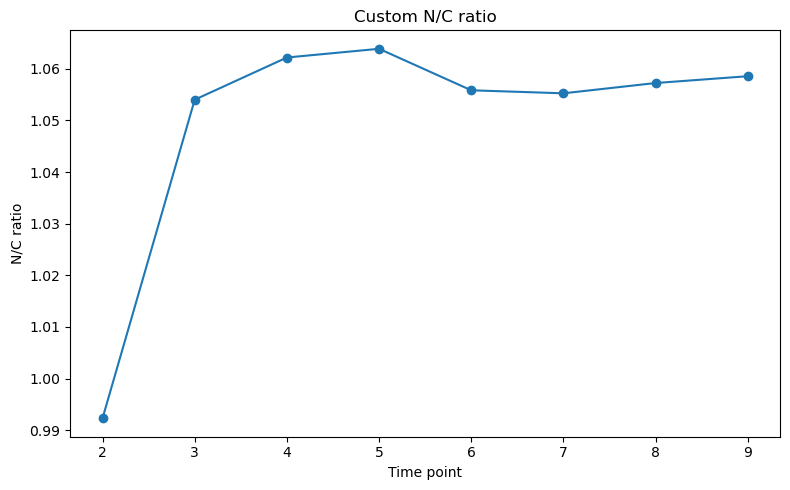

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio_custom"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("Custom N/C ratio")
plt.tight_layout()
plt.show()

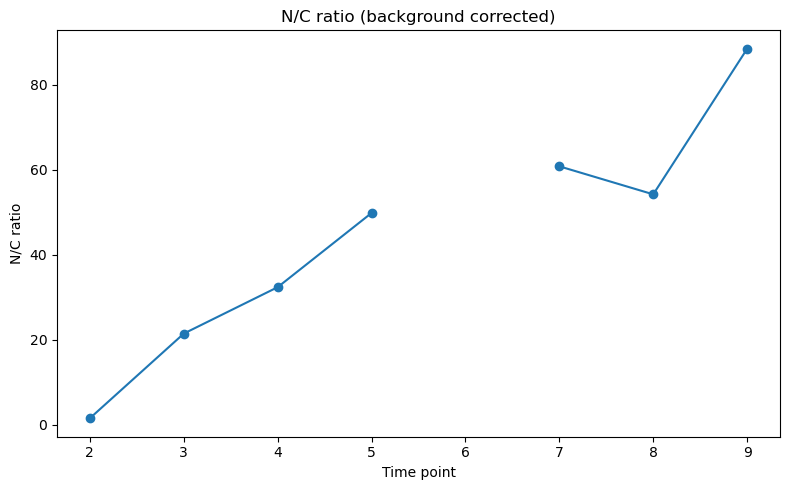

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio_bgsub"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("N/C ratio (background corrected)")
plt.tight_layout()
plt.show()

## Time-course plots

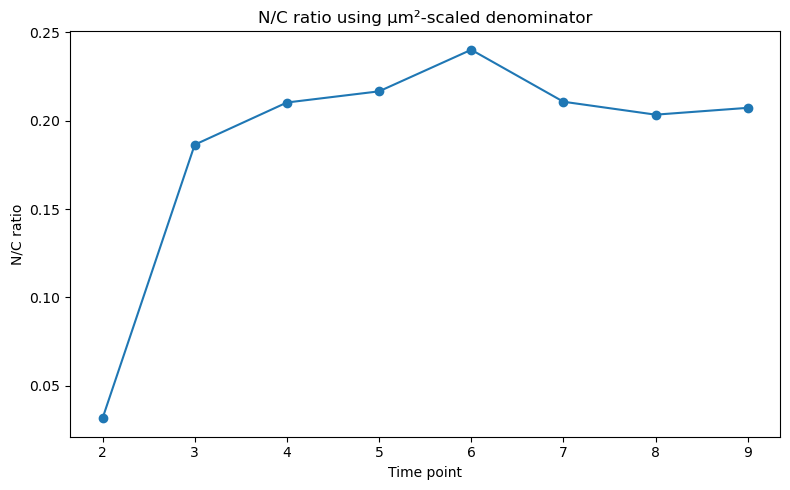

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nc_ratio_um2_denominator"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("N/C ratio")
plt.title("N/C ratio using µm²-scaled denominator")
plt.tight_layout()
plt.show()


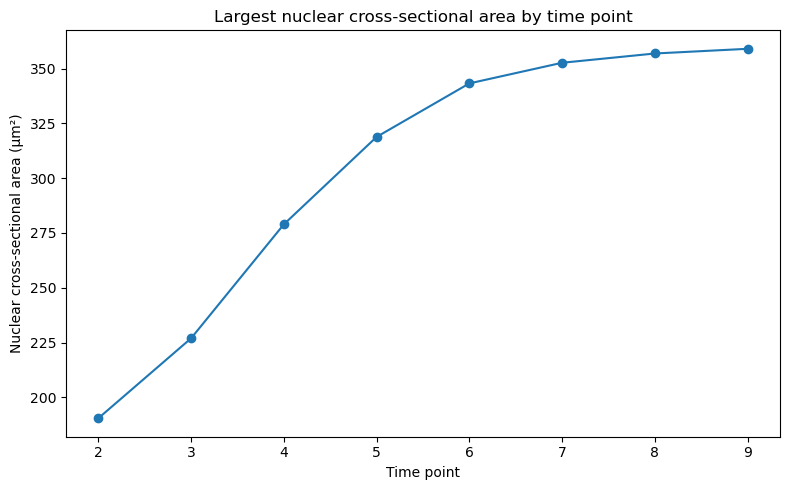

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["nuclear_area_um2"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("Nuclear cross-sectional area (µm²)")
plt.title("Largest nuclear cross-sectional area by time point")
plt.tight_layout()
plt.show()


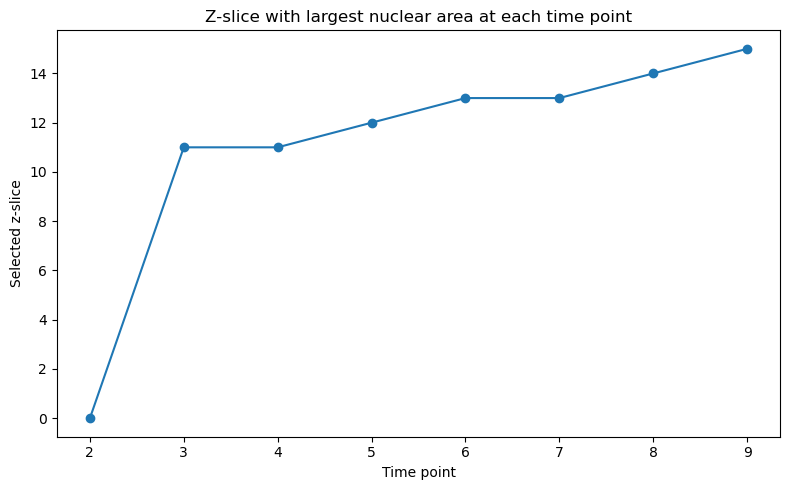

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(
    largest_area_df_filtered["t"],
    largest_area_df_filtered["z"],
    marker="o"
)
plt.xlabel("Time point")
plt.ylabel("Selected z-slice")
plt.title("Z-slice with largest nuclear area at each time point")
plt.tight_layout()
plt.show()


## Save outputs

In [ ]:
OUTPUT_DIR = DATA_ROOT / "Python_Coding" / "machine_learning" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results_path = OUTPUT_DIR / "halo_analysis_results_all_tz_v2_1.csv"
largest_path = OUTPUT_DIR / "halo_analysis_largest_area_per_timepoint_v2_1.csv"
filtered_path = OUTPUT_DIR / "halo_analysis_largest_area_filtered_v2_1.csv"

results_df.to_csv(results_path, index=False)
largest_area_df.to_csv(largest_path, index=False)
largest_area_df_filtered.to_csv(filtered_path, index=False)

print(results_path)
print(largest_path)
print(filtered_path)
